# 1 · Calibration

This notebook **computes** the household-energy model's demand parameter set from SERL
smart-meter data, parameter by parameter, in the order the paper's demand equation
presents them: the baseline load, the heating load, then the occupancy load. Running it
top to bottom fits every coefficient live and assembles them into the calibrated config.

Each section calls the fit that produces its parameter, so what you see plotted is what
was just computed, not a number read off disk. Every parameter is fitted from SERL,
cited from the literature, or deliberately neutralised; there are no correction
multipliers. The one exception to "compute it here" is cost, not principle: the four
cohort levels (baseline anchors and heating slopes) require running the agent-based
model for ~6 minutes, so they sit behind `RUN_COHORT_FIT` and read a cached result by
default. Everything else is a fast regression computed on every run.

SERL is the calibration target throughout. The DESNZ sub-national statistics are held
out for validation in notebook 3, and we never tune to them.

> `SERL daily/diurnal targets` → **[ this notebook computes the fits ]** →
> `results/calibration_v7_cohort/calibrated_config.yaml` → read by `2_sensitivity` and
> `3_validation`.

> Use the project `.venv` (Python 3.12).

In [ ]:
import sys, os
from pathlib import Path
import numpy as np, pandas as pd, yaml
import matplotlib.pyplot as plt

REPO = Path.cwd()
while not (REPO / "household_energy").exists() and REPO != REPO.parent:
    REPO = REPO.parent
os.chdir(REPO)
SCRIPTS = REPO / "research" / "applied" / "scripts"
sys.path.insert(0, str(REPO)); sys.path.insert(0, str(SCRIPTS))

DATA     = REPO / "data" / "serl_8963_targets"
DAILY    = DATA / "daily_targets.csv"               # input for the regression fits
DIURNAL  = DATA / "diurnal_targets_hourly_mean.csv" # input for the hourly fits
SHIPPED  = REPO / "household_energy" / "calibrated_config.yaml"   # structural defaults + neutralised channels
OUT_CFG  = REPO / "results" / "calibration_v7_cohort" / "calibrated_config.yaml"
YEAR = 2023

# Compute the cohort levels here too: this runs the model (~6 min) and is the one expensive
# fit. Set False only to read the cached result for fast iteration on the rest of the notebook.
RUN_COHORT_FIT = True

import run_paths
RUN_DATE = None
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3, "font.size": 10})

# Import the fit functions this notebook computes with (one code path with the CLIs).
import fit_heating_setpoint, fit_area_scaling, fit_sap_band_mult, fit_age_mult
import fit_elec_baseline_area, fit_presence_spikes, fit_diurnal_profile, calibrate_serl
from fit_cohort_params import fit_cohort_params, serl_targets
from fit_monthly_profile import fit as fit_monthly
from household_energy.serl_calibration_v2 import load_serl_targets

SERL = serl_targets()
print("Python", sys.version.split()[0], "| computing fits for year", YEAR)
print("SERL cohort targets (kWh/yr):", {k: round(v) for k, v in SERL.items()})

## 1.1 · The demand equation

For dwelling $d$ at hour $h$, demand is the sum of three terms, capped and split between
the metered fuels:

$$
E_{d,h} \;=\; \min\!\big( B_d + H_{d,h} + S_{d,h},\; E_{\max}\big),
\qquad
\begin{cases}
E^{\mathrm{elec}}_{d,h} = B^{\mathrm{elec}}_d + S_{d,h} + \mathbb{1}[d\ \mathrm{electric}]\,H_{d,h}\\
E^{\mathrm{gas}}_{d,h}  = B^{\mathrm{gas}}_d + \mathbb{1}[d\ \mathrm{gas}]\,H_{d,h}
\end{cases}
$$

$B_d$ is the weather-independent baseline, $H_{d,h}$ the temperature-driven heating load,
and $S_{d,h}$ the occupancy load. The notebook computes these three in this order.

| term | symbol | what it is | computed in |
|---|---|---|---|
| baseline | $B_d$ | appliances, lighting, always-on standby (carries hot water) | §1.2 |
| heating | $H_{d,h}$ | climate-driven space heat | §1.3 |
| occupancy | $S_{d,h}$ | per-person load while present | §1.4 |

The summer baseline carries the non-heating loads including hot water, so there is no
separate hot-water term. Cooling and two neutralised behavioural multipliers sit outside
the formula and are gathered in §1.5.

## 1.2 · Baseline load $B_d = A_b\,\mu_{t(d)}\,m^{E}_{a(d)}$

The baseline is the floor a home draws regardless of weather. The first cell computes the
two **levels**, the per-cohort anchors $A_b$ (and the heating slopes used in §1.3), by
running the model once and inverting against the SERL cohort targets. This is the only
slow step; with `RUN_COHORT_FIT = False` it reads the cached result. The cell also
computes the within-day and within-year baseline shapes from SERL.

The anchors are the no-multiplier rule made concrete: gas-heated and electric-heated homes
get their own fitted anchor, and the electric-to-gas ratio (~1.34) falls out of the SERL
all-electric baseline rather than being imposed.

In [2]:
COHORT = REPO / "results" / "calibration_serl_fits" / "cohort_params.yaml"
if RUN_COHORT_FIT:
    cp = fit_cohort_params(30, write=True)        # ~6 min model run
else:
    cp = yaml.safe_load(COHORT.read_text())       # cached result of that run

mp, *_ = fit_monthly(write=False)                                       # monthly profiles (computed)
dp = {"base_profile_24h_electric": fit_diurnal_profile.fit_profile(DIURNAL, year=YEAR)["profile"]}  # diurnal (computed)
gas_anchor = yaml.safe_load(SHIPPED.read_text())["model"]["baseline_anchor_gas_kwh_per_hour"]

print("Baseline anchors A_b (kWh/h):")
print(f"  gas-heated electricity   {cp['baseline_anchor_elec_kwh_per_hour']}")
print(f"  electric-heated          {cp['baseline_anchor_elec_kwh_per_hour_electric']}")
print(f"  gas non-heating          {gas_anchor:.4f}   (cooking + hot water)")
ratio = cp["baseline_anchor_elec_kwh_per_hour_electric"] / cp["baseline_anchor_elec_kwh_per_hour"]
print(f"  electric/gas ratio       {ratio:.2f}")

Baseline anchors A_b (kWh/h):
  gas-heated electricity   0.3
  electric-heated          0.402
  gas non-heating          0.2886   (cooking + hot water)
  electric/gas ratio       1.34


The anchor is scaled by two SERL-fitted structural multipliers, both computed here from the
summer panel where heating is off: floor area $m^E_a$ and building type $\mu_t$. The
building-type multiplier comes from the pooled summer-by-building-type fit
(`calibrate_serl.calibrate`); the floor-area multiplier from `fit_elec_baseline_area`.
Keeping the size term separate from the per-person term in §1.4 is what makes the
occupancy unconfounding there possible.

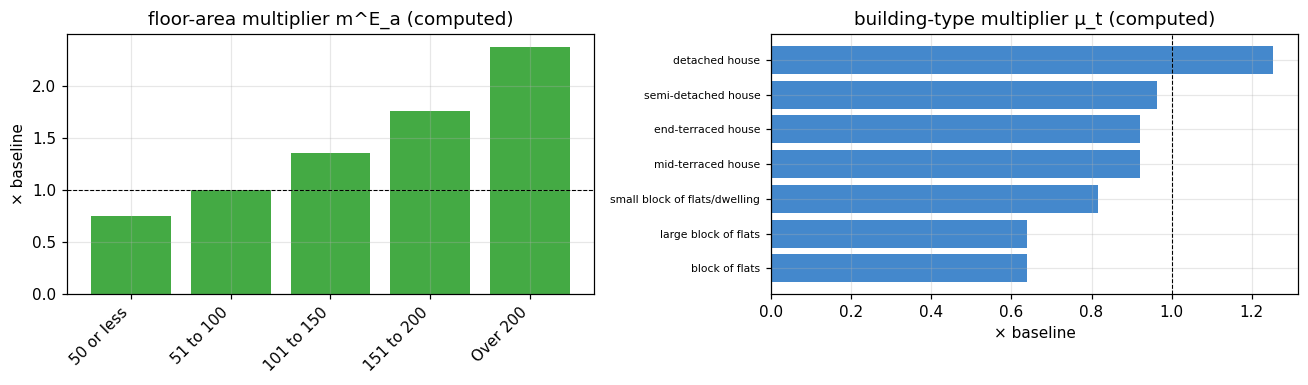

In [3]:
eb = fit_elec_baseline_area.fit(DAILY, year=YEAR)                       # floor-area multiplier (computed)
daily_targets, _ = load_serl_targets(REPO)
bt = calibrate_serl.calibrate(daily_targets, years=[YEAR])["building_type_multipliers"]   # building-type (computed)

fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
s = pd.Series(eb["baseline_elec_area_bands"])
ax[0].bar(range(len(s)), s.values, color="#4a4"); ax[0].axhline(1, color="k", lw=0.7, ls="--")
ax[0].set_xticks(range(len(s))); ax[0].set_xticklabels(s.index, rotation=45, ha="right")
ax[0].set(title="floor-area multiplier m^E_a (computed)", ylabel="× baseline")

pt = pd.Series(bt["gas"]).sort_values()
ax[1].barh(range(len(pt)), pt.values, color="#48c"); ax[1].axvline(1, color="k", lw=0.7, ls="--")
ax[1].set_yticks(range(len(pt)))
ax[1].set_yticklabels([k.replace(" converted in to flats", "") for k in pt.index], fontsize=7)
ax[1].set(title="building-type multiplier μ_t (computed)", xlabel="× baseline")
plt.tight_layout(); plt.show()

The level is given within-day and within-year shape by mean-1.0 multipliers, both computed
above (`fit_diurnal_profile` and `fit_monthly_profile`), mean-preserving so the annual total
is unchanged.

> **Note for the paper.** The monthly baseline profile is a v7 addition not yet in the
> `methodology_3_3` baseline equation, which treats $B_d$ as constant.

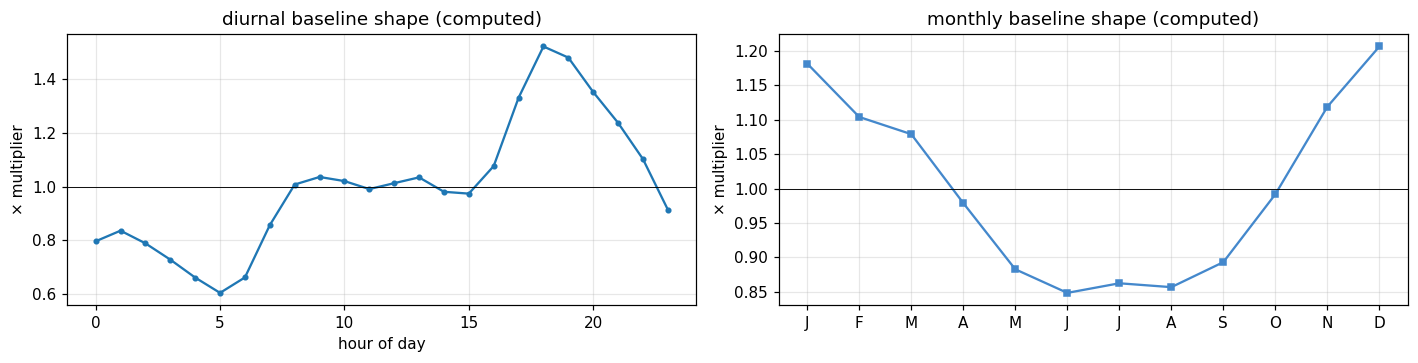

monthly baseline day-weighted mean = 1.000 (-> 1.0)


In [4]:
M = ["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"]
fig, ax = plt.subplots(1, 2, figsize=(13, 3.4))
ax[0].plot(range(24), dp["base_profile_24h_electric"], "-o", ms=3); ax[0].axhline(1, color="k", lw=0.6)
ax[0].set(title="diurnal baseline shape (computed)", xlabel="hour of day", ylabel="× multiplier")
ax[1].plot(range(1, 13), mp["base_profile_12_electric"], "-s", ms=4, color="#48c"); ax[1].axhline(1, color="k", lw=0.6)
ax[1].set_xticks(range(1, 13)); ax[1].set_xticklabels(M)
ax[1].set(title="monthly baseline shape (computed)", ylabel="× multiplier")
plt.tight_layout(); plt.show()
print(f"monthly baseline day-weighted mean = {mp['diagnostics']['base_weighted_mean_check']:.3f} (-> 1.0)")

## 1.3 · Heating load $H_{d,h} = \min(s_d\,g_{d,h}\,\rho_d,\;C_d)\,w_{d,h}\,\pi_h$

The setpoint is computed here from SERL gas binned by outdoor temperature: gas use is flat
across mild weather and turns on sharply as it falls, and we fit that hinge
(`fit_heating_setpoint`). The kink is the temperature at which heating begins, near 16.5 °C.

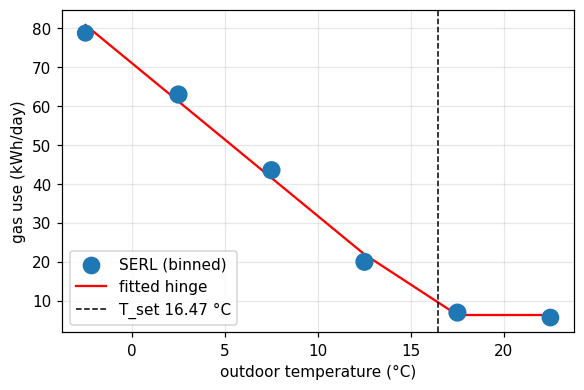

heating setpoint T_set = 16.47 °C  |  weighted RMSE = 1.63 kWh/day


In [5]:
sp_fit = fit_heating_setpoint.fit(DAILY, year=YEAR)                     # setpoint (computed)
bands = pd.DataFrame(sp_fit["diagnostics"]["bands"]); sp = sp_fit["heating_setpoint_C"]
fig, ax = plt.subplots(figsize=(6, 3.8))
ax.scatter(bands.temp_C_midpoint, bands.observed_kwh_per_day,
           s=bands.n_rounded / bands.n_rounded.max() * 120, label="SERL (binned)", zorder=3)
ax.plot(bands.temp_C_midpoint, bands.fitted_kwh_per_day, "r-", label="fitted hinge")
ax.axvline(sp, color="k", ls="--", lw=1, label=f"T_set {sp:.2f} °C")
ax.set(xlabel="outdoor temperature (°C)", ylabel="gas use (kWh/day)"); ax.legend(); plt.show()
print(f"heating setpoint T_set = {sp:.2f} °C  |  weighted RMSE = {sp_fit['fit']['rmse_weighted_kwh_per_day']:.2f} kWh/day")

The base slopes $s_d$ are the heating half of the cohort fit computed in §1.2 (gas slope
re-scaled to the seasonal profile; electric slope fitted so electric-heated homes reproduce
their SERL heating).

In [6]:
print("Base heating slopes s_d (kWh per °C·h), from the §1.2 cohort fit:")
print(f"  gas       {cp['heating_slope_kWh_per_deg']}")
print(f"  electric  {cp['heating_slope_kWh_per_deg_electric']}")

Base heating slopes s_d (kWh per °C·h), from the §1.2 cohort fit:
  gas       0.1846
  electric  0.06934


The efficiency-and-era factor $\rho_d$ is three SERL-fitted multipliers, each computed here
from monthly gas by band (`fit_area_scaling`, `fit_sap_band_mult`, `fit_age_mult`): floor
area, SAP band, and building age. Property type enters $\rho_d$ as an **assumed** archetype
(not SERL-fitted), flagged as such.

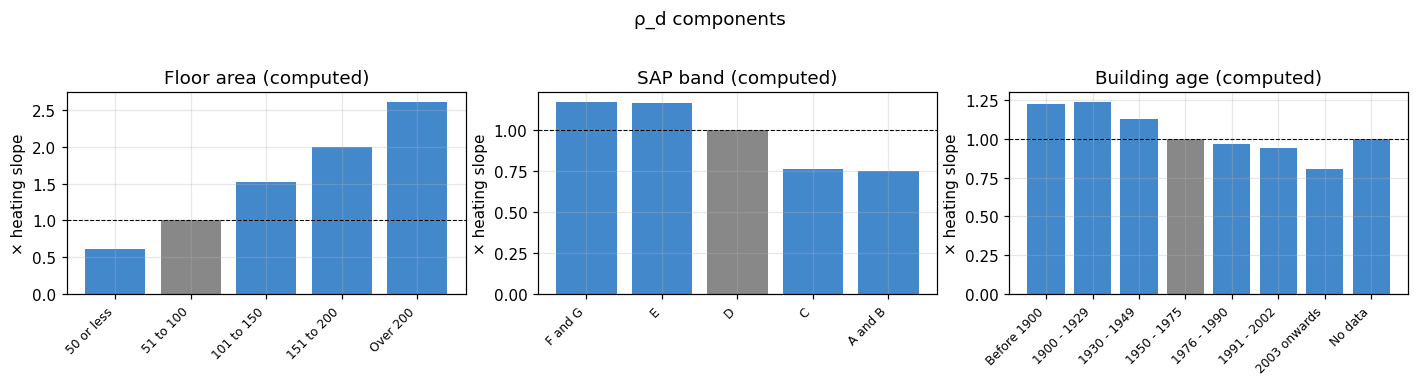

property-type heating multiplier in ρ_d (ASSUMED archetype, household_energy/agent.py):
  mid-terraced house                                   1.00
  semi-detached house                                  1.10
  small block of flats/dwelling converted in to flats  0.90
  large block of flats                                 0.85
  block of flats                                       0.85
  end-terraced house                                   1.05
  detached house                                       1.20
  flat in mixed use building                           0.90


In [7]:
ar = fit_area_scaling.fit(DAILY, year=YEAR)        # floor-area heating multiplier (computed)
sa = fit_sap_band_mult.fit(DAILY, year=YEAR)       # SAP-band heating multiplier (computed)
ag = fit_age_mult.fit(DAILY, year=YEAR)            # building-age heating multiplier (computed)

panels = [("Floor area", ar, "heat_slope_area_bands"),
          ("SAP band",   sa, "sap_band_mult_heating_gas"),
          ("Building age", ag, "building_age_mult_heating_gas")]
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
for ax, (title, dct, key) in zip(axes, panels):
    s = pd.Series(dct[key])
    colors = ["#888" if band == dct["reference_band"] else "#48c" for band in s.index]
    ax.bar(range(len(s)), s.values, color=colors); ax.axhline(1, color="k", lw=0.7, ls="--")
    ax.set_xticks(range(len(s))); ax.set_xticklabels(s.index, rotation=45, ha="right", fontsize=8)
    ax.set(title=f"{title} (computed)", ylabel="× heating slope")
plt.suptitle("ρ_d components", y=1.02); plt.tight_layout(); plt.show()

from household_energy.agent import PROPERTY_TYPE_MULT_HEAT
print("property-type heating multiplier in ρ_d (ASSUMED archetype, household_energy/agent.py):")
for k, v in PROPERTY_TYPE_MULT_HEAT.items():
    print(f"  {k:52s} {v:.2f}")

The within-day $\pi_h$ is flat in v7; the active seasonal shape is the monthly heating
profile computed in §1.2, peaking in December and falling to about 0 in summer.

> **Note for the paper.** The monthly heating profile is a v7 addition not yet in the
> `methodology_3_3` heating equation.

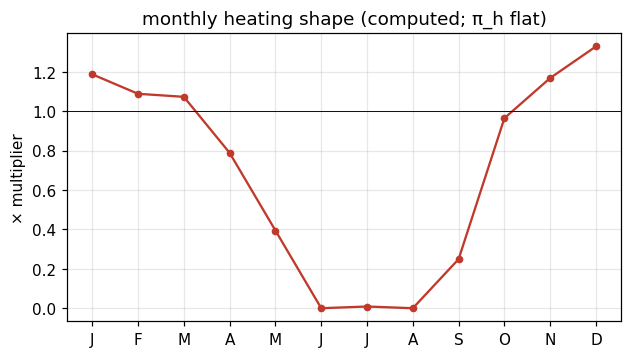

heating profile HDD-weighted mean = 1.000 (-> 1.0)


In [8]:
fig, ax = plt.subplots(figsize=(6.5, 3.4))
ax.plot(range(1, 13), mp["heating_month_profile_12"], "-o", ms=4, color="#c0392b")
ax.axhline(1, color="k", lw=0.6); ax.set_xticks(range(1, 13)); ax.set_xticklabels(M)
ax.set(title="monthly heating shape (computed; π_h flat)", ylabel="× multiplier"); plt.show()
print(f"heating profile HDD-weighted mean = {mp['diagnostics']['heating_weighted_mean_check']:.3f} (-> 1.0)")

## 1.4 · Occupancy load $S_{d,h}$

The per-person load is computed here (`fit_presence_spikes`) by unconfounding standby from
behaviour: a naive occupant slope of ~0.098 kWh/h is confounded by size-correlated standby,
so we partial that out and use the behavioural remainder, ~0.031 kWh/h. The sleep multiplier
is fitted to ~0; the waking window (07–22) and the away load are cited inputs SERL cannot
identify.

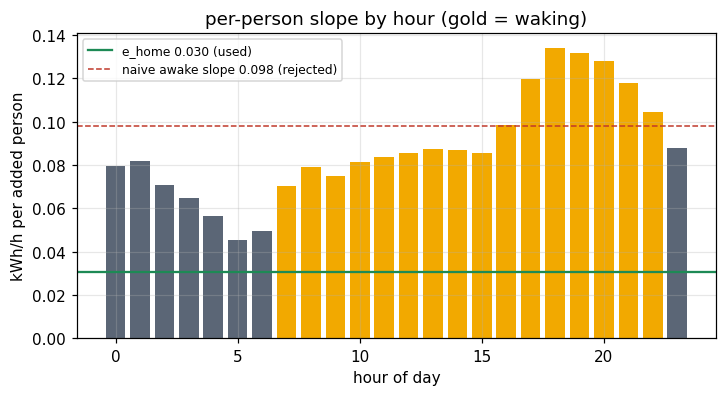

  behavioural per-person (used)  0.030 kWh/h   (e_home)
  naive awake slope (rejected)   0.098 kWh/h
  sleep multiplier (fitted)      0.00
  away-from-home load (cited)    0.01 kWh/h   (e_away)


In [9]:
ps = fit_presence_spikes.fit(DIURNAL, year=YEAR)                        # per-person load (computed)
d  = ps["diagnostics"]
ph = pd.DataFrame(d["per_hour_occ"]).T; ph.index = ph.index.astype(int); ph = ph.sort_index()
awake = set(d["awake_hours"])
fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.bar(ph.index, ph["per_person_kwh_per_hour"],
       color=["#f2a900" if h in awake else "#5b6676" for h in ph.index])
ax.axhline(ps["energy_per_person_home"], color="#1d8a55", lw=1.5,
           label=f"e_home {ps['energy_per_person_home']:.3f} (used)")
ax.axhline(d["naive_per_person_awake_kWh_per_h"], color="#c0392b", lw=1, ls="--",
           label=f"naive awake slope {d['naive_per_person_awake_kWh_per_h']:.3f} (rejected)")
ax.set(xlabel="hour of day", ylabel="kWh/h per added person", title="per-person slope by hour (gold = waking)")
ax.legend(fontsize=8); plt.show()
print(f"  behavioural per-person (used)  {ps['energy_per_person_home']:.3f} kWh/h   (e_home)")
print(f"  naive awake slope (rejected)   {d['naive_per_person_awake_kWh_per_h']:.3f} kWh/h")
print(f"  sleep multiplier (fitted)      {ps['sleep_home_spike_mult']:.2f}")
print(f"  away-from-home load (cited)    {ps['energy_per_person_away']:.2f} kWh/h   (e_away)")

Who is present, and when, comes from three behavioural archetypes (Parent, Worker,
Homebody). These are **assumed**, not fitted: a smart-meter panel cannot recover individual
diaries. SERL fixes the totals; the schedules govern within-day timing.

In [10]:
from household_energy.agent import SCHEDULE_PROFILES
sched = pd.DataFrame(SCHEDULE_PROFILES)
sched["leaves home"] = sched["leave"].map(lambda h: "never" if pd.isna(h) else f"{int(h):02d}:00")
sched["returns"]     = sched["return"].map(lambda h: "n/a" if pd.isna(h) else f"{int(h):02d}:00")
print("presence archetypes (assumed; household_energy/agent.py):\n")
print(sched[["name", "leaves home", "returns"]].to_string(index=False))

presence archetypes (assumed; household_energy/agent.py):

    name leaves home returns
  Parent       07:00   15:00
  Worker       09:00   17:00
Homebody       never     n/a


## 1.5 · Outside the three-term formula

Cooling is a small latent-cooling structural default (not SERL-fitted). Two further
multiplier channels, `wealth_mult_map` and `sap_scaling`, are neutralised to 1.0 because
SERL identifies neither. These are read from the structural defaults, not computed.

In [11]:
cfg0 = yaml.safe_load(SHIPPED.read_text())["model"]
for name in ["sap_scaling", "wealth_mult_map"]:
    vals = cfg0[name]
    print(f"{name:16s} all 1.0: {all(abs(float(v) - 1.0) < 1e-9 for v in vals.values())}")
print(f"heat_slope_max (slope cap): {cfg0['heat_slope_max']} kWh/°C")

sap_scaling      all 1.0: True
wealth_mult_map  all 1.0: True
heat_slope_max (slope cap): 5.0 kWh/°C


## 1.6 · Assemble the calibrated config

The config is built **from the values computed above**, overlaid on the structural defaults
and neutralised channels (the keys SERL does not fit). Nothing here is re-read from a stale
artefact: the setpoint, the multipliers, the building-type and per-person fits, the profiles,
and the cohort levels are all the objects produced in §1.2–§1.4.

In [12]:
base = yaml.safe_load(SHIPPED.read_text())   # structural defaults + neutralised channels
m = base["model"]

# Computed upstream fits (§1.2–1.4):
m["heating_trigger_temp_C"]        = sp_fit["heating_setpoint_C"]
m["heat_slope_area_bands"]         = ar["heat_slope_area_bands"]
m["sap_band_mult_heating_gas"]     = sa["sap_band_mult_heating_gas"]
m["building_age_mult_heating_gas"] = ag["building_age_mult_heating_gas"]
m["baseline_elec_area_bands"]      = eb["baseline_elec_area_bands"]
m["property_type_mult_base_gas"]      = bt["gas"]
m["property_type_mult_base_electric"] = bt["electric"]
m["energy_per_person_home"] = ps["energy_per_person_home"]
m["energy_per_person_away"] = ps["energy_per_person_away"]
m["awake_home_spike_mult"]  = ps.get("awake_home_spike_mult", 1.0)
m["sleep_home_spike_mult"]  = ps["sleep_home_spike_mult"]
# Computed cohort levels (the ~6-min model fit) + shapes:
m.update({k: v for k, v in cp.items() if k != "diagnostics"})
m.pop("electric_heated_baseline_mult", None)
m["base_profile_24h_electric"] = dp["base_profile_24h_electric"]
m["base_profile_12_electric"]  = mp["base_profile_12_electric"]
m["heating_month_profile_12"]  = mp["heating_month_profile_12"]

OUT_CFG.parent.mkdir(parents=True, exist_ok=True)
yaml.safe_dump(base, open(OUT_CFG, "w"), sort_keys=False)
print(f"wrote {OUT_CFG.relative_to(REPO)}  ({len(m)} model keys, all from computed fits)")

RUN = run_paths.start_run(RUN_DATE)
yaml.safe_dump(base, open(RUN / "calibrated_config.yaml", "w"), sort_keys=False)
run_paths.write_manifest(RUN, stage="calibration", setpoint=m["heating_trigger_temp_C"],
                         fitted={k: cp[k] for k in cp if k != "diagnostics"})
print(f"run snapshot: {RUN.relative_to(REPO)} (recorded as latest)")

wrote results/calibration_v7_cohort/calibrated_config.yaml  (24 model keys, all from computed fits)
run snapshot: results/runs/2026-06-24 (recorded as latest)


## 1.7 · Coverage check

Every tunable parameter in the model block should be accounted for by one of the terms
above. The check maps each key to its term and fails loudly on anything undocumented.

In [13]:
DOCUMENTED = {
    "baseline_anchor_elec_kwh_per_hour": "1.2 B", "baseline_anchor_gas_kwh_per_hour": "1.2 B",
    "baseline_anchor_elec_kwh_per_hour_electric": "1.2 B", "use_separate_fuel_baseline_anchors": "1.2 B",
    "property_type_mult_base_gas": "1.2 B", "property_type_mult_base_electric": "1.2 B",
    "baseline_elec_area_bands": "1.2 B", "base_profile_24h_electric": "1.2 B", "base_profile_12_electric": "1.2 B",
    "heating_trigger_temp_C": "1.3 H", "heating_slope_kWh_per_deg": "1.3 H",
    "heating_slope_kWh_per_deg_electric": "1.3 H", "heat_slope_max": "1.3 H",
    "heating_months": "1.3 H", "heating_month_profile_12": "1.3 H",
    "heat_slope_area_bands": "1.3 H", "sap_band_mult_heating_gas": "1.3 H", "building_age_mult_heating_gas": "1.3 H",
    "energy_per_person_home": "1.4 S", "energy_per_person_away": "1.4 S",
    "awake_home_spike_mult": "1.4 S", "sleep_home_spike_mult": "1.4 S",
    "sap_scaling": "1.5", "wealth_mult_map": "1.5",
}
cfg = yaml.safe_load(OUT_CFG.read_text())["model"]
undocumented = [k for k in cfg if k not in DOCUMENTED]
print(f"{len(cfg)} model keys; {len(cfg) - len(undocumented)} documented, {len(undocumented)} not.")
assert not undocumented, f"UNDOCUMENTED parameters: {undocumented}"
print("every tunable parameter maps to a term of the demand equation (or §1.5).")

24 model keys; 24 documented, 0 not.
every tunable parameter maps to a term of the demand equation (or §1.5).


## 1.8 · Promote (optional)

Ships the assembled model block to `household_energy/calibrated_config.yaml`, the canonical
config every entry point loads. Off by default; set `PROMOTE` to ship.

In [14]:
PROMOTE = False
if PROMOTE:
    import subprocess
    subprocess.run([sys.executable, str(SCRIPTS / "promote_config.py"),
                    "--source", str(OUT_CFG), "--label", "v7_cohort"], check=True)
    print("promoted to household_energy/calibrated_config.yaml")
else:
    print("PROMOTE is False. Config ready at", OUT_CFG.relative_to(REPO))

PROMOTE is False. Config ready at results/calibration_v7_cohort/calibrated_config.yaml
